# Trader Performance vs Market Sentiment Analysis

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [4]:
# loading data

df1 = pd.read_csv("fear_greed_index.csv")
df2 = pd.read_csv("historical_data.csv")

### Market Sentiment Dataset

In [5]:
df1.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


### Historical Dataset

In [6]:
df2.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


## Dataset 1: Market Sentiment

In [8]:
### Checking Dataset Shape

df1.shape

(2644, 4)

#
The dataset contains 2644 rows and 4 columns.

In [10]:
### Checking Dataset Information

df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


#
The dataset contains 4 columns.

In [11]:
### Checking Missing Values

df1.isnull().sum()

timestamp         0
value             0
classification    0
date              0
dtype: int64

#
There are no missing values in this dataset.

In [12]:
### Checking Duplicate Rows

df1.duplicated().sum()

np.int64(0)

#
No duplicates were found in this dataset.

In [13]:
### Converting Date Column

df1["date"] = pd.to_datetime(df1["date"])

df1.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


#
The date column is now in datetime format.

In [14]:
# Checking categories

df1["classification"].value_counts()

classification
Fear             781
Greed            633
Extreme Fear     508
Neutral          396
Extreme Greed    326
Name: count, dtype: int64

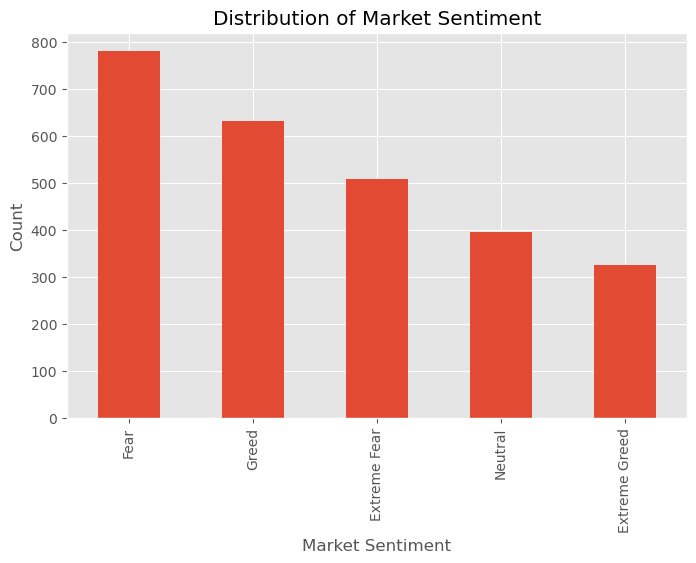

In [15]:
### Now creating chart

plt.figure(figsize=(8,5))

df1["classification"].value_counts().plot(kind="bar")

plt.title("Distribution of Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Count")

plt.show()

#
The dataset contains different categories such as Fear, Greed, Extreme Fear, Extreme Greed, and Neutral.

### Dataset 2 : Historical Trade Data

In [16]:
## Checking Dataset Shape

df2.shape

(211224, 16)

#
The dataset contains 211224 rows and 16 columns.

In [17]:
## Checking Dataset Information

df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

In [18]:
### Checking Missing Values

df2.isnull().sum()

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

#
There are no missing values in this dataset.

In [19]:
## Checking Duplicate Rows

df2.duplicated().sum()

np.int64(0)

#
No duplicates were found in this dataset.

In [20]:
# Converting timestamps and align the datasets by date

df2["Timestamp IST"] = pd.to_datetime(df2["Timestamp IST"], dayfirst=True)

df2["Date"] = df2["Timestamp IST"].dt.date

df2["Date"] = pd.to_datetime(df2["Date"])

df2.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,Date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02


#
The timestamp has been converted into date format.

In [21]:
## Checking Trading Direction

df2["Direction"].value_counts()

Direction
Open Long                    49895
Close Long                   48678
Open Short                   39741
Close Short                  36013
Sell                         19902
Buy                          16716
Spot Dust Conversion           142
Short > Long                    70
Long > Short                    57
Auto-Deleveraging                8
Liquidated Isolated Short        1
Settlement                       1
Name: count, dtype: int64

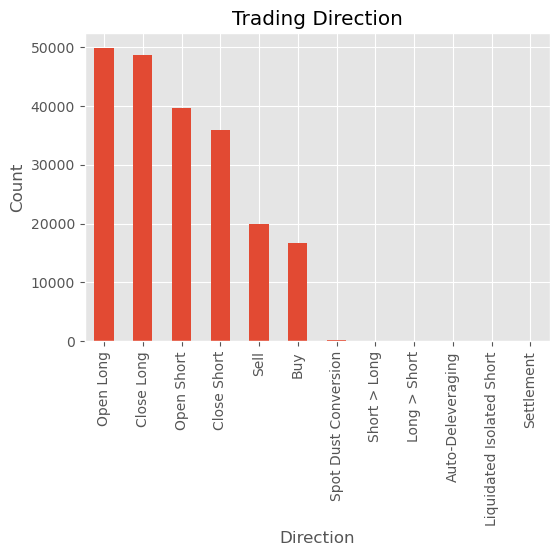

In [22]:
plt.figure(figsize=(6,4))

df2["Direction"].value_counts().plot(kind="bar")

plt.title("Trading Direction")
plt.xlabel("Direction")
plt.ylabel("Count")

plt.show()

#
The dataset contains both long and short positions.

## Merge Both Datasets

In [23]:
merged_df = pd.merge(
    df2,
    df1[["date", "classification", "value"]],
    left_on="Date",
    right_on="date",
    how="left"
)

merged_df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,Date,date,classification,value
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,2024-12-02,Extreme Greed,80.0
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,2024-12-02,Extreme Greed,80.0
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,2024-12-02,Extreme Greed,80.0
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,2024-12-02,Extreme Greed,80.0
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,2024-12-02,Extreme Greed,80.0


#
The datasets have been merged successfully using the date column.

In [27]:
## Checking Merged Dataset

merged_df.shape

(211224, 20)

In [28]:
merged_df[["Date", "classification", "value"]].head()

,Date,classification,value
0,2024-12-02,Extreme Greed,80.0
1,2024-12-02,Extreme Greed,80.0
2,2024-12-02,Extreme Greed,80.0
3,2024-12-02,Extreme Greed,80.0
4,2024-12-02,Extreme Greed,80.0


#
The merged dataset now contains both trading information and market sentiment data

In [30]:
#### Now I will calculate the daily profit or loss for each trader by grouping the data using account and date.


merged_df.columns

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp', 'Date', 'date', 'classification', 'value'],
      dtype='object')

## Daily PnL per Trader

In [33]:
daily_pnl = merged_df.groupby(["Date", "Account"])["Closed PnL"].sum().reset_index()

daily_pnl.head()

,Date,Account,Closed PnL
0,2023-05-01,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,0.000000
1,2023-12-05,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.000000
2,2023-12-14,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,-205.434737
3,2023-12-15,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,-24.632034
4,2023-12-16,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.000000


#
This table shows the total profit or loss made by each trader on each day.

### Win Rate

In [34]:
merged_df["Win"] = merged_df["Closed PnL"] > 0

win_rate = merged_df.groupby("Account")["Win"].mean().reset_index()

win_rate["Win"] = win_rate["Win"] * 100

win_rate.rename(columns={"Win": "Win Rate (%)"}, inplace=True)

win_rate.head()

,Account,Win Rate (%)
0,0x083384f897ee0f19899168e3b1bec365f52a9012,35.961236
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,44.271978
2,0x271b280974205ca63b716753467d5a371de622ab,30.191651
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,43.858463
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,51.991355


#
The win rate shows the percentage of profitable trades for each trader. 

#### Average Trade Size

In [35]:
avg_trade_size = merged_df.groupby("Account")["Size USD"].mean().reset_index()

avg_trade_size.rename(columns={"Size USD": "Average Trade Size (USD)"}, inplace=True)

avg_trade_size.head()

,Account,Average Trade Size (USD)
0,0x083384f897ee0f19899168e3b1bec365f52a9012,16159.576734
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,1653.226327
2,0x271b280974205ca63b716753467d5a371de622ab,8893.000898
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,507.626933
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3138.894782


#
This table shows the average trade size for each trader.

### Number of Trades per Day

In [36]:
trades_per_day = merged_df.groupby("Date").size().reset_index(name="Number of Trades")

trades_per_day.head()

,Date,Number of Trades
0,2023-05-01,3
1,2023-12-05,9
2,2023-12-14,11
3,2023-12-15,2
4,2023-12-16,3


#
This table shows how many trades were made each day.

### Long/Short Ratio

In [37]:
long_short = merged_df["Direction"].value_counts().reset_index()

long_short.columns = ["Direction", "Count"]

long_short

,Direction,Count
0,Open Long,49895
1,Close Long,48678
2,Open Short,39741
3,Close Short,36013
4,Sell,19902
5,Buy,16716
6,Spot Dust Conversion,142
7,Short > Long,70
8,Long > Short,57
9,Auto-Deleveraging,8


#
This table shows the total number of long and short positions in the dataset.

#### Chart for Long/Short Positions

In [40]:
long_count = merged_df["Direction"].str.contains("Long", case=False, na=False).sum()

short_count = merged_df["Direction"].str.contains("Short", case=False, na=False).sum()

long_short = pd.DataFrame({
    "Position": ["Long", "Short"],
    "Count": [long_count, short_count]
})

long_short

,Position,Count
0,Long,98700
1,Short,75882


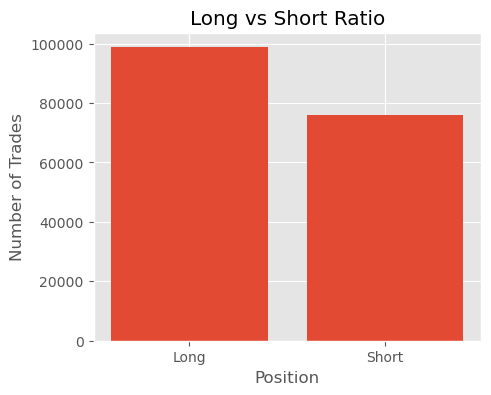

In [41]:
plt.figure(figsize=(5,4))

plt.bar(long_short["Position"], long_short["Count"])

plt.title("Long vs Short Ratio")
plt.xlabel("Position")
plt.ylabel("Number of Trades")

plt.show()

#
The chart compares the total number of long and short positions.

#### Analysis 1: Average PnL by Market Sentiment

In [42]:
pnl_by_sentiment = merged_df.groupby("classification")["Closed PnL"].mean().reset_index()

pnl_by_sentiment

,classification,Closed PnL
0,Extreme Fear,34.537862
1,Extreme Greed,67.892861
2,Fear,54.290400
3,Greed,42.743559
4,Neutral,34.307718


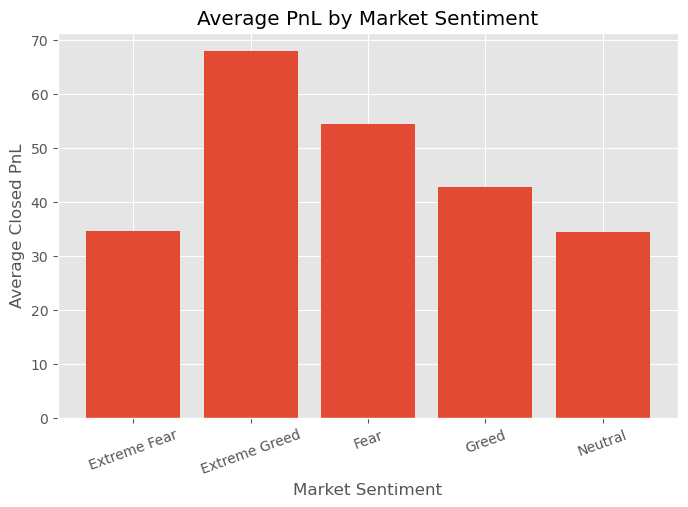

In [43]:
plt.figure(figsize=(8,5))

plt.bar(pnl_by_sentiment["classification"], pnl_by_sentiment["Closed PnL"])

plt.title("Average PnL by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Closed PnL")

plt.xticks(rotation=20)

plt.show()

The average PnL is highest during **Extreme Greed** days (around 67.89). 
It is lower during **Fear**, **Greed**, **Extreme Fear**, and **Neutral** days. 
This suggests that traders earned higher average profits when the market was in Extreme Greed.

### Analysis 2: Win Rate by Market Sentiment

In [44]:
win_rate_sentiment = merged_df.groupby("classification")["Win"].mean().reset_index()

win_rate_sentiment["Win"] = win_rate_sentiment["Win"] * 100

win_rate_sentiment

,classification,Win
0,Extreme Fear,37.060748
1,Extreme Greed,46.494299
2,Fear,42.076750
3,Greed,38.482794
4,Neutral,39.699093


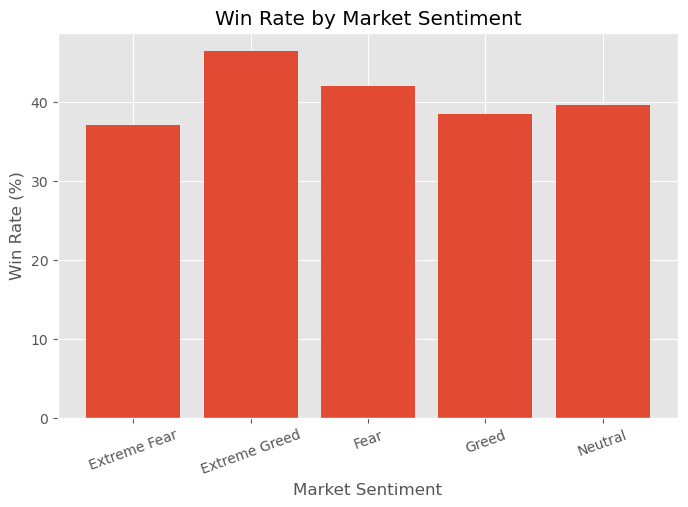

In [45]:
plt.figure(figsize=(8,5))

plt.bar(win_rate_sentiment["classification"], win_rate_sentiment["Win"])

plt.title("Win Rate by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Win Rate (%)")

plt.xticks(rotation=20)

plt.show()

The win rate is also highest during **Extreme Greed** days (about 46.5%). 
The lowest win rate is during **Extreme Fear** days (about 37.1%). 
This shows that traders had more successful trades during Extreme Greed than during Fear.

### Trade Frequency by Market Sentiment

In [46]:
trade_frequency = merged_df.groupby("classification").size().reset_index(name="Number of Trades")

trade_frequency

,classification,Number of Trades
0,Extreme Fear,21400
1,Extreme Greed,39992
2,Fear,61837
3,Greed,50303
4,Neutral,37686


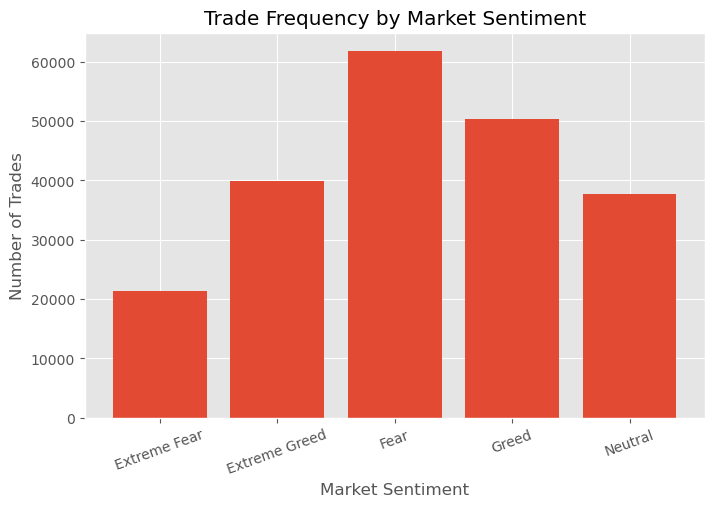

In [47]:
plt.figure(figsize=(8,5))

plt.bar(trade_frequency["classification"], trade_frequency["Number of Trades"])

plt.title("Trade Frequency by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Number of Trades")

plt.xticks(rotation=20)

plt.show()

#
The number of trades changes across different market sentiment categories. 
This shows that traders do not trade the same way in every market condition.

#### Position Size by Market Sentiment

In [48]:
position_size = merged_df.groupby("classification")["Size USD"].mean().reset_index()

position_size

,classification,Size USD
0,Extreme Fear,5349.731843
1,Extreme Greed,3112.251565
2,Fear,7816.109931
3,Greed,5736.884375
4,Neutral,4782.732661


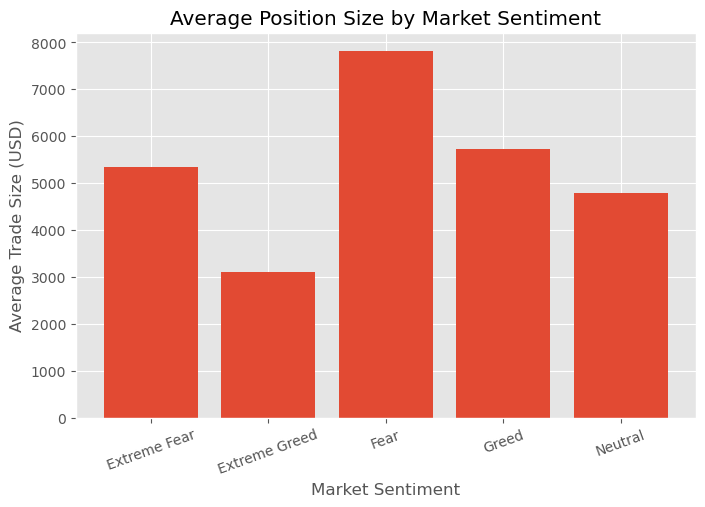

In [49]:
plt.figure(figsize=(8,5))

plt.bar(position_size["classification"], position_size["Size USD"])

plt.title("Average Position Size by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Trade Size (USD)")

plt.xticks(rotation=20)

plt.show()

#
The average trade size changes across different market sentiment categories.

### Trader Segmentation

In [50]:
trade_count = merged_df.groupby("Account").size().reset_index(name="Total Trades")

trade_count.head()

,Account,Total Trades
0,0x083384f897ee0f19899168e3b1bec365f52a9012,3818
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,7280
2,0x271b280974205ca63b716753467d5a371de622ab,3809
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,13311
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3239


In [51]:
trade_count["Trader Type"] = trade_count["Total Trades"].apply(
    lambda x: "Frequent Trader" if x > trade_count["Total Trades"].median() else "Infrequent Trader"
)

trade_count.head()

,Account,Total Trades,Trader Type
0,0x083384f897ee0f19899168e3b1bec365f52a9012,3818,Frequent Trader
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,7280,Frequent Trader
2,0x271b280974205ca63b716753467d5a371de622ab,3809,Frequent Trader
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,13311,Frequent Trader
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3239,Infrequent Trader


In [52]:
segment = trade_count["Trader Type"].value_counts().reset_index()

segment.columns = ["Trader Type", "Count"]

segment

,Trader Type,Count
0,Frequent Trader,16
1,Infrequent Trader,16


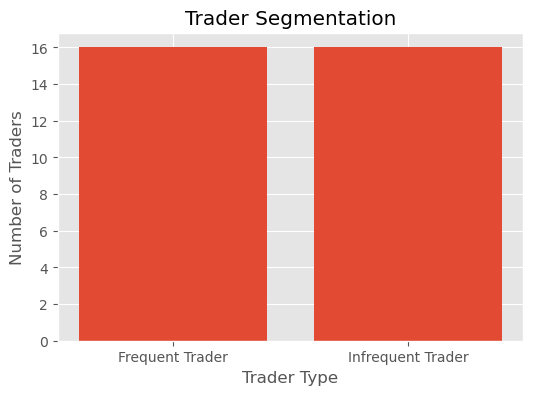

In [53]:
plt.figure(figsize=(6,4))

plt.bar(segment["Trader Type"], segment["Count"])

plt.title("Trader Segmentation")
plt.xlabel("Trader Type")
plt.ylabel("Number of Traders")

plt.show()

#
The traders were divided into frequent and infrequent groups based on their trading activity.

### Key Insights

### Insight 1

The average PnL was highest during **Extreme Greed** days, showing that traders generally earned better profits when market sentiment was strongly positive.

### Insight 2

The win rate was also highest during **Extreme Greed** days, while **Extreme Fear** had the lowest win rate. This suggests that traders were more successful during positive market conditions.

### Insight 3

Trading activity and average position size changed across different market sentiment categories. This indicates that market sentiment may influence trader behavior and decision-making.

### Strategy Recommendations

### Strategy 1

During Fear or Extreme Fear market conditions, traders should consider using smaller position sizes and follow better risk management, as trading performance was comparatively lower.

### Strategy 2

During Extreme Greed market conditions, traders may consider momentum-based trading strategies while maintaining proper risk management, since both average PnL and win rate were higher.

## Note

The assignment mentions leverage distribution as one of the example metrics. However, the provided historical trader dataset does not include a leverage column. Therefore, leverage analysis could not be performed, and the analysis focused on the available trading metrics.

# Conclusion

This project analyzed the relationship between Bitcoin market sentiment and Hyperliquid trader performance. After cleaning and merging both datasets, different trading metrics were analyzed. The results showed that market sentiment has an impact on trader performance and trading behavior. Overall, traders performed better during Extreme Greed market conditions, while Fear and Extreme Fear were associated with lower profitability and win rates.